In [14]:
import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense, Activation
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

In [5]:
DRIVE_URL = '/content/drive/MyDrive/VISION-4/RETO2/'
LOCAL_PATH = os.getcwd()

In [6]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [7]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [8]:
LANDUSE_DIR = BASE + "/landuse"

CLASSES = ["airplane", "denseresidential", "harbor"]

IMG_SIZE = 224
CHANNELS = 3
TEST_SIZE = 0.25
RANDOM_STATE = 42

BATCH_SIZE = 32
EPOCHS_BASELINE = 30
EPOCHS_RESNET = 20

LEARNING_RATE_BASELINE = 1e-3
LEARNING_RATE_RESNET = 1e-4

NUM_CLASSES = len(CLASSES)

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [9]:
for class_name in CLASSES:
    class_path = os.path.join(LANDUSE_DIR, class_name)
    print(class_path, "->", os.path.exists(class_path))

C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\RETO2/landuse\airplane -> True
C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\RETO2/landuse\denseresidential -> True
C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\RETO2/landuse\harbor -> True


In [10]:
data = []
labels = []

for class_name in CLASSES:
    class_path = os.path.join(LANDUSE_DIR, class_name)

    if not os.path.exists(class_path):
        raise FileNotFoundError(f"No existe la carpeta: {class_path}")

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ]

    print(f"Clase {class_name}: {len(files)} imágenes")

    for file in files:
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img is None:
            print(f"No se pudo leer: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype("float32") / 255.0

        data.append(img)
        labels.append(class_name)

data = np.array(data)
labels = np.array(labels)

print("Total imágenes:", len(data))
print("Shape dataset:", data.shape)

Clase airplane: 500 imágenes
Clase denseresidential: 500 imágenes
Clase harbor: 500 imágenes
Total imágenes: 1500
Shape dataset: (1500, 224, 224, 3)


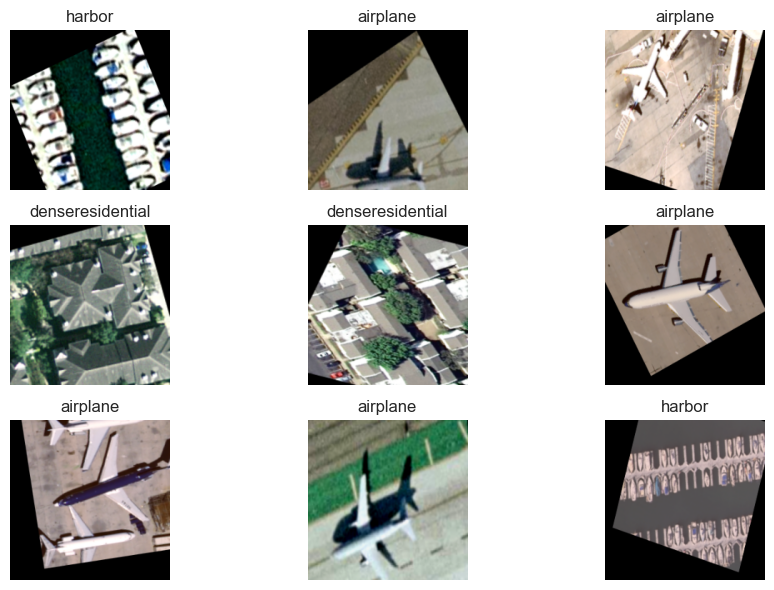

In [11]:
plt.figure(figsize=(10, 6))

for i in range(9):
    idx = random.randint(0, len(data) - 1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(data[idx])
    plt.title(labels[idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

print("Clases detectadas:", lb.classes_)
print("Shape etiquetas:", labels_encoded.shape)

unique, counts = np.unique(labels, return_counts=True)
print("Distribución del dataset:")
print(dict(zip(unique, counts)))

Clases detectadas: ['airplane' 'denseresidential' 'harbor']
Shape etiquetas: (1500, 3)
Distribución del dataset:
{np.str_('airplane'): np.int64(500), np.str_('denseresidential'): np.int64(500), np.str_('harbor'): np.int64(500)}


In [15]:
trainX, testX, trainY, testY = train_test_split(
    data,
    labels_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels_encoded
)

print("Train X:", trainX.shape)
print("Test X:", testX.shape)
print("Train Y:", trainY.shape)
print("Test Y:", testY.shape)

print("Distribución train:", trainY.sum(axis=0))
print("Distribución test:", testY.sum(axis=0))

Train X: (1125, 224, 224, 3)
Test X: (375, 224, 224, 3)
Train Y: (1125, 3)
Test Y: (375, 3)
Distribución train: [375 375 375]
Distribución test: [125 125 125]


In [16]:
y_train_labels = trainY.argmax(axis=1)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [17]:
tf.keras.backend.clear_session()

In [18]:
baseline_model = Sequential(name="CNN_Secuencial_LandUse")

baseline_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
baseline_model.add(BatchNormalization())
baseline_model.add(Activation("relu"))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))
baseline_model.add(Dropout(0.25))

baseline_model.add(Conv2D(64, (3, 3), padding="same"))
baseline_model.add(BatchNormalization())
baseline_model.add(Activation("relu"))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))
baseline_model.add(Dropout(0.25))

baseline_model.add(Conv2D(128, (3, 3), padding="same"))
baseline_model.add(BatchNormalization())
baseline_model.add(Activation("relu"))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))
baseline_model.add(Dropout(0.35))

baseline_model.add(GlobalAveragePooling2D())

baseline_model.add(Dense(128, activation="relu"))
baseline_model.add(Dropout(0.50))

baseline_model.add(Dense(NUM_CLASSES, activation="softmax"))

baseline_model.summary()

C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Secuencial_LandUse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
baseline_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_BASELINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
history_baseline = baseline_model.fit(
    trainX,
    trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_baseline,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.6133 - loss: 0.8401 - val_accuracy: 0.3333 - val_loss: 1.3038 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7538 - loss: 0.5944 - val_accuracy: 0.3333 - val_loss: 1.9158 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8231 - loss: 0.4825 - val_accuracy: 0.3333 - val_loss: 2.3709 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8436 - loss: 0.4178 - val_accuracy: 0.3333 - val_loss: 2.5688 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8782 - loss: 0.3317 - val_accuracy: 0.3333 - val_loss: 2.9251 - learning_rate: 5.0000e-04
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8889 - loss: 0.3076 - val_accuracy: 0.3333 - val_loss: 3.1429 - learning_rate: 5.0000e-04
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8923 - loss: 0.2850

In [13]:
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, testX_data, testY_data, class_names, title):
    predictions = model.predict(testX_data, batch_size=BATCH_SIZE)

    y_true = testY_data.argmax(axis=1)
    y_pred = predictions.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)

    print(f"\nResultados del modelo: {title}")
    print(f"Accuracy: {acc:.4f}")
    print("\nReporte de clasificación:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Matriz de confusión - {title}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.show()

    return acc, predictions

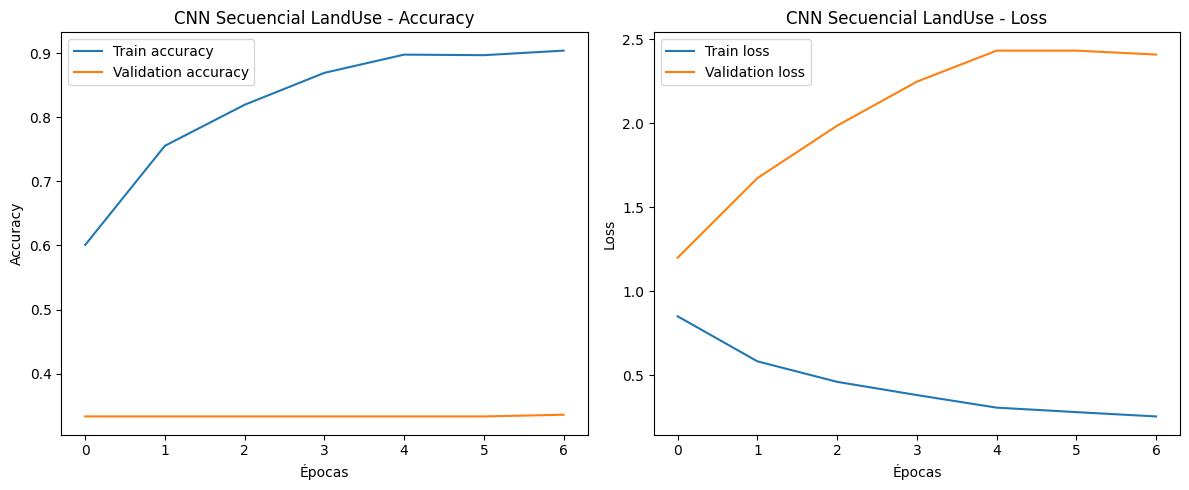

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

Resultados del modelo: CNN Secuencial LandUse
Accuracy: 0.3333

Reporte de clasificación:
                  precision    recall  f1-score   support

        airplane       0.33      1.00      0.50       125
denseresidential       0.00      0.00      0.00       125
          harbor       0.00      0.00      0.00       125

        accuracy                           0.33       375
       macro avg       0.11      0.33      0.17       375
    weighted avg       0.11      0.33      0.17       375



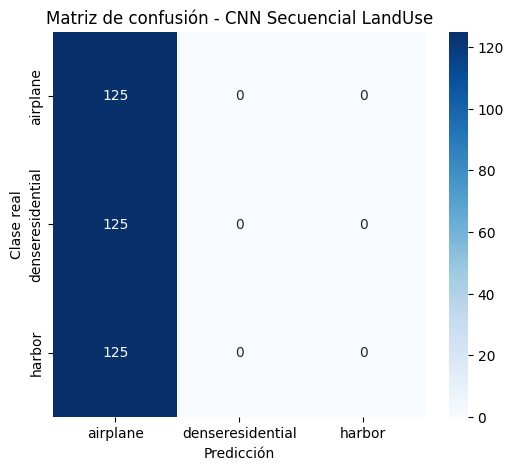

In [14]:
plot_training_history(history_baseline, "CNN Secuencial LandUse")

acc_baseline, predictions_baseline = evaluate_model(
    baseline_model,
    testX,
    testY,
    lb.classes_,
    "CNN Secuencial LandUse"
)

In [24]:
trainX_resnet = preprocess_input((trainX * 255).astype("float32"))
testX_resnet = preprocess_input((testX * 255).astype("float32"))

In [16]:
tf.keras.backend.clear_session()

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)
)

base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.50)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(
    inputs=base_resnet.input,
    outputs=output,
    name="ResNet50_LandUse_Transfer_Learning"
)

resnet_model.summary()

Model: "ResNet50_LandUse_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
resnet_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_RESNET),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_resnet = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [18]:
history_resnet = resnet_model.fit(
    trainX_resnet,
    trainY,
    validation_data=(testX_resnet, testY),
    epochs=EPOCHS_RESNET,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_resnet,
    verbose=1
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.6880 - loss: 0.7671 - val_accuracy: 0.9760 - val_loss: 0.1314 - learning_rate: 1.0000e-04
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9440 - loss: 0.1718 - val_accuracy: 1.0000 - val_loss: 0.0512 - learning_rate: 1.0000e-04
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9742 - loss: 0.0945 - val_accuracy: 1.0000 - val_loss: 0.0311 - learning_rate: 1.0000e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9831 - loss: 0.0679 - val_accuracy: 0.9973 - val_loss: 0.0218 - learning_rate: 1.0000e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9858 - loss: 0.0464 - val_accuracy: 1.0000 - val_loss: 0.0160 - learning_rate: 1.0000e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9902 - loss: 0.0437 - val_accuracy: 1.0000 - val_loss: 0.0135 - learning_rate: 1.0000e-04
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy:

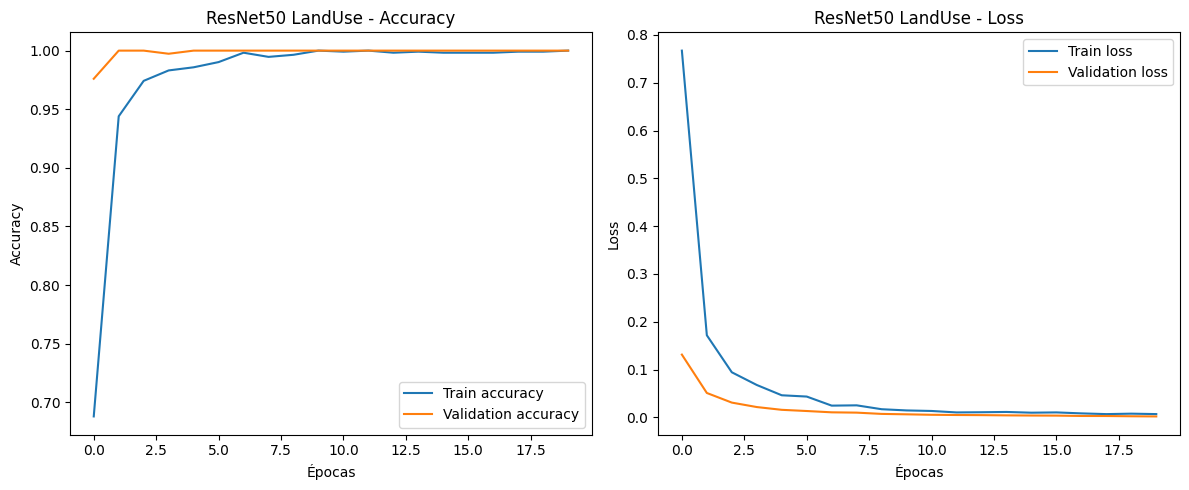

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step

Resultados del modelo: ResNet50 LandUse Transfer Learning
Accuracy: 1.0000

Reporte de clasificación:
                  precision    recall  f1-score   support

        airplane       1.00      1.00      1.00       125
denseresidential       1.00      1.00      1.00       125
          harbor       1.00      1.00      1.00       125

        accuracy                           1.00       375
       macro avg       1.00      1.00      1.00       375
    weighted avg       1.00      1.00      1.00       375



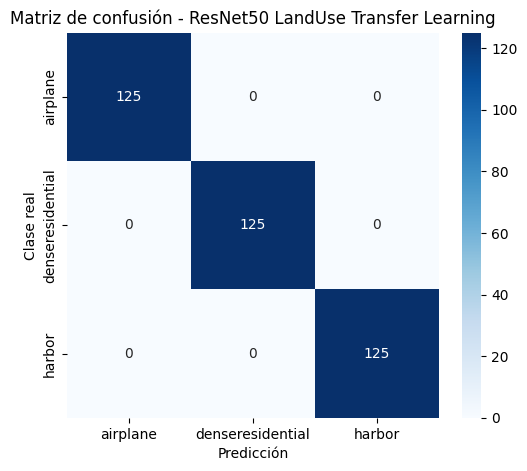

In [19]:
plot_training_history(history_resnet, "ResNet50 LandUse")

acc_resnet, predictions_resnet = evaluate_model(
    resnet_model,
    testX_resnet,
    testY,
    lb.classes_,
    "ResNet50 LandUse Transfer Learning"
)

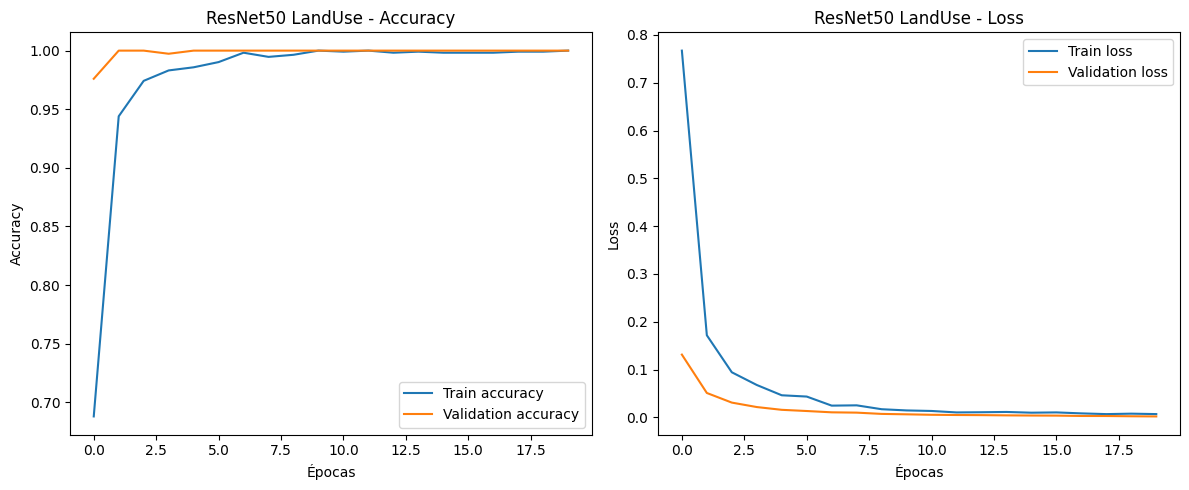

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step

Resultados del modelo: ResNet50 LandUse Transfer Learning
Accuracy: 1.0000

Reporte de clasificación:
                  precision    recall  f1-score   support

        airplane       1.00      1.00      1.00       125
denseresidential       1.00      1.00      1.00       125
          harbor       1.00      1.00      1.00       125

        accuracy                           1.00       375
       macro avg       1.00      1.00      1.00       375
    weighted avg       1.00      1.00      1.00       375



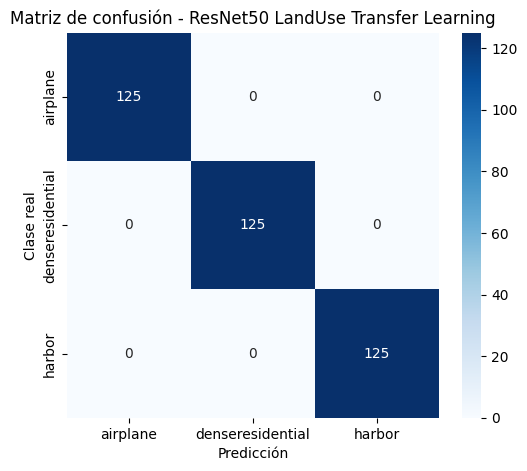

In [20]:
plot_training_history(history_resnet, "ResNet50 LandUse")

acc_resnet, predictions_resnet = evaluate_model(
    resnet_model,
    testX_resnet,
    testY,
    lb.classes_,
    "ResNet50 LandUse Transfer Learning"
)

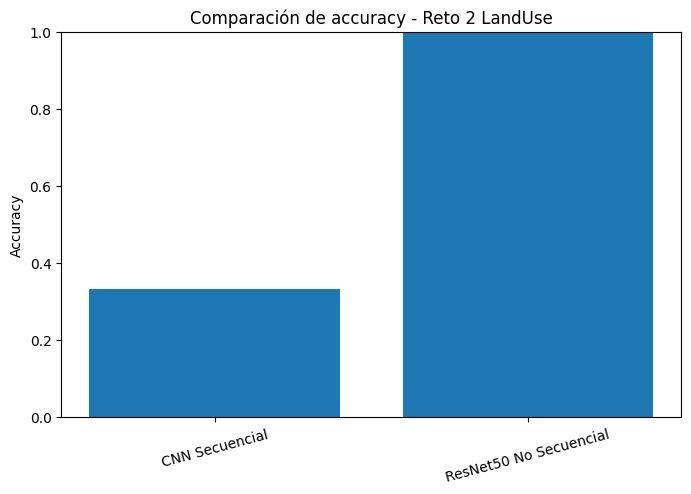

CNN Secuencial: 0.3333
ResNet50 No Secuencial: 1.0000


In [21]:
results = {
    "CNN Secuencial": acc_baseline,
    "ResNet50 No Secuencial": acc_resnet
}

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.title("Comparación de accuracy - Reto 2 LandUse")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


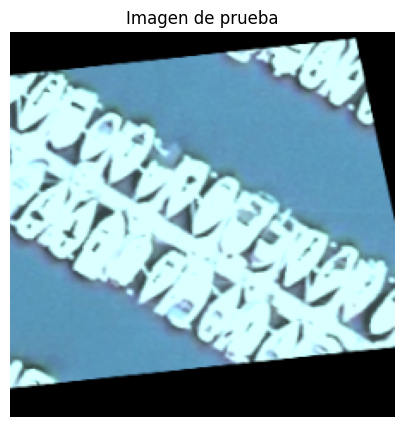

Clase real: harbor
Predicción CNN secuencial: airplane
Predicción ResNet50: harbor


In [22]:
rand_pos = random.randint(0, len(testX) - 1)

img = testX[rand_pos]
true_class = lb.classes_[np.argmax(testY[rand_pos])]

pred_baseline = baseline_model.predict(np.expand_dims(img, axis=0))
pred_class_baseline = lb.classes_[np.argmax(pred_baseline)]

img_resnet = preprocess_input(np.expand_dims((img * 255).astype("float32"), axis=0))
pred_resnet = resnet_model.predict(img_resnet)
pred_class_resnet = lb.classes_[np.argmax(pred_resnet)]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

print("Clase real:", true_class)
print("Predicción CNN secuencial:", pred_class_baseline)
print("Predicción ResNet50:", pred_class_resnet)

In [23]:
EVIDENCE_DIR = BASE + '/landuse'
os.makedirs(EVIDENCE_DIR, exist_ok=True)

baseline_model.save(os.path.join(EVIDENCE_DIR, "cnn_secuencial_landuse.keras"))
resnet_model.save(os.path.join(EVIDENCE_DIR, "resnet50_landuse.keras"))


def save_evidence(model, testX_data, testY_data, model_name):
    predictions = model.predict(testX_data)
    y_true = testY_data.argmax(axis=1)
    y_pred = predictions.argmax(axis=1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=lb.classes_,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(os.path.join(EVIDENCE_DIR, f"reporte_{model_name}.csv"))

    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=lb.classes_, columns=lb.classes_)
    df_cm.to_csv(os.path.join(EVIDENCE_DIR, f"matriz_confusion_{model_name}.csv"))


save_evidence(
    baseline_model,
    testX,
    testY,
    "cnn_secuencial"
)

save_evidence(
    resnet_model,
    testX_resnet,
    testY,
    "resnet50"
)

print("Evidencias guardadas en:", EVIDENCE_DIR)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Evidencias guardadas en: /content/drive/MyDrive/VISION-4/RETO2/evidencias_landuse
